In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = 'data/'

tx   = pd.read_csv(DATA_DIR + 'transaction_data.csv')
prod = pd.read_csv(DATA_DIR + 'product.csv')
dem  = pd.read_csv(DATA_DIR + 'hh_demographic.csv')
coup = pd.read_csv(DATA_DIR + 'coupon_redempt.csv')
camp = pd.read_csv(DATA_DIR + 'campaign_table.csv')

print(f"Transactions : {tx.shape}")
print(f"Products     : {prod.shape}")
print(f"Demographics : {dem.shape}")
print(f"Coupon redemp: {coup.shape}")
print(f"Campaigns    : {camp.shape}")

Transactions : (2595732, 12)
Products     : (92353, 7)
Demographics : (801, 8)
Coupon redemp: (2318, 4)
Campaigns    : (7208, 3)


In [2]:
# ── Step 1: Isolate returns (SALES_VALUE <= 0) as a separate signal ──
returns = tx[tx['SALES_VALUE'] <= 0].copy()
tx_clean = tx[tx['SALES_VALUE'] > 0].copy()

# Return rate per household (will become a feature later)
total_visits   = tx.groupby('household_key')['BASKET_ID'].nunique()
return_baskets = returns.groupby('household_key')['BASKET_ID'].nunique()
return_rate_sr = (return_baskets / total_visits).fillna(0).rename('return_rate')

print(f"Rows removed (returns/zero-value) : {len(tx) - len(tx_clean):,}")
print(f"Clean transaction rows remaining  : {len(tx_clean):,}")
print(f"Households with at least 1 return : {(return_rate_sr > 0).sum():,}")

# ── Step 2: Also remove rows with QUANTITY <= 0 ──
tx_clean = tx_clean[tx_clean['QUANTITY'] > 0].reset_index(drop=True)
print(f"After QUANTITY filter             : {len(tx_clean):,}")

# ── Step 3: Define study window ──
STUDY_START = tx_clean['DAY'].min()   # DAY 1
STUDY_END   = tx_clean['DAY'].max()   # DAY 711 (approx)
CHURN_WINDOW = 90                      # last 90 days = churn observation period
CHURN_CUTOFF = STUDY_END - CHURN_WINDOW

print(f"\nStudy window : DAY {STUDY_START} → DAY {STUDY_END}")
print(f"Churn cutoff : DAY {CHURN_CUTOFF}  (no purchase after this = churned)")

Rows removed (returns/zero-value) : 18,850
Clean transaction rows remaining  : 2,576,882
Households with at least 1 return : 2,143
After QUANTITY filter             : 2,576,815

Study window : DAY 1 → DAY 711
Churn cutoff : DAY 621  (no purchase after this = churned)


In [3]:
tx_train = tx_clean[tx_clean['DAY'] <= CHURN_CUTOFF].copy()

rfm = tx_train.groupby('household_key').agg(
    recency   = ('DAY',         lambda x: CHURN_CUTOFF - x.max()),  # days since last purchase
    frequency = ('BASKET_ID',  'nunique'),                          # unique shopping trips
    monetary  = ('SALES_VALUE', 'sum'),                              # total spend
    avg_basket= ('SALES_VALUE', lambda x: x.sum() /
                  tx_train.loc[x.index, 'BASKET_ID'].nunique()),    # avg spend per trip
    active_days=('DAY',         'nunique'),                          # days with any purchase
    first_day  =('DAY',         'min'),                              # tenure start
).reset_index()

# Tenure = how long they've been a customer (in days)
rfm['tenure_days'] = CHURN_CUTOFF - rfm['first_day']

# Purchase rate = frequency / tenure (shopping intensity)
rfm['purchase_rate'] = rfm['frequency'] / rfm['tenure_days'].replace(0, np.nan)

rfm.drop(columns=['first_day'], inplace=True)

print(f"RFM matrix shape: {rfm.shape}")
print(f"\nSample:")
rfm.head(3)

RFM matrix shape: (2499, 8)

Sample:


,household_key,recency,frequency,monetary,avg_basket,active_days,tenure_days,purchase_rate
0,1,1,72,3693.77,51.302361,66,570,0.126316
1,2,1,43,1740.67,40.480698,43,518,0.083012
2,3,45,44,2554.98,58.067727,43,508,0.086614


In [4]:
# ── Items per basket ──
items_per_basket = tx_train.groupby(['household_key', 'BASKET_ID'])['QUANTITY'].sum()
basket_features = items_per_basket.groupby('household_key').agg(
    avg_items_per_basket = 'mean',
    max_items_per_basket = 'max',
).reset_index()

# ── Shopping time preference ──
# TRANS_TIME is an int like 900=9am, 1430=2:30pm
tx_train['hour'] = tx_train['TRANS_TIME'] // 100

# Bin into Morning / Afternoon / Evening
tx_train['time_of_day'] = pd.cut(
    tx_train['hour'],
    bins  = [0, 12, 17, 24],
    labels= ['morning', 'afternoon', 'evening']
)

time_pref = (tx_train.groupby(['household_key', 'time_of_day'])
             ['BASKET_ID'].nunique()
             .unstack(fill_value=0))
time_pref.columns = [f'trips_{c}' for c in time_pref.columns]
time_pref = time_pref.reset_index()

# ── Store loyalty — does HH always use the same store? ──
store_counts = tx_train.groupby('household_key')['STORE_ID'].nunique().rename('unique_stores_visited')
top_store_share = (tx_train.groupby(['household_key', 'STORE_ID'])['BASKET_ID']
                   .nunique()
                   .groupby('household_key')
                   .apply(lambda x: x.max() / x.sum())).rename('top_store_share')

basket_features = (basket_features
    .merge(time_pref,                        on='household_key', how='left')
    .merge(store_counts.reset_index(),        on='household_key', how='left')
    .merge(top_store_share.reset_index(),     on='household_key', how='left')
)

print(f"Basket features shape: {basket_features.shape}")
basket_features.head(3)

Basket features shape: (2499, 8)


,household_key,avg_items_per_basket,max_items_per_basket,trips_morning,trips_afternoon,trips_evening,unique_stores_visited,top_store_share
0,1,23.916667,62,27,36,9,2,0.986111
1,2,16.767442,68,3,17,23,5,0.581395
2,3,192.545455,6949,1,29,14,3,0.886364


In [5]:
# ── Coupon redemption rate ──
# Limit to training window baskets only
train_baskets = tx_train.groupby('household_key')['BASKET_ID'].nunique().rename('total_baskets')

coup_train = coup[coup['household_key'].isin(tx_train['household_key'])]
coup_counts = coup_train.groupby('household_key')['COUPON_UPC'].count().rename('coupons_redeemed')

promo_features = train_baskets.reset_index().merge(
    coup_counts.reset_index(), on='household_key', how='left'
)
promo_features['coupons_redeemed'] = promo_features['coupons_redeemed'].fillna(0)
promo_features['coupon_redemption_rate'] = (
    promo_features['coupons_redeemed'] / promo_features['total_baskets']
)

# ── Campaign response — was HH targeted & did they buy during campaign? ──
targeted_hh = camp['household_key'].unique()
promo_features['was_targeted_by_campaign'] = (
    promo_features['household_key'].isin(targeted_hh).astype('int')
)

# ── % of spend that was on discount (RETAIL_DISC + COUPON_DISC) ──
tx_train['total_discount'] = (
    tx_train['RETAIL_DISC'].abs() + tx_train['COUPON_DISC'].abs()
)
discount_features = tx_train.groupby('household_key').agg(
    total_spend    = ('SALES_VALUE',   'sum'),
    total_discount = ('total_discount', 'sum')
)
discount_features['pct_spend_on_discount'] = (
    discount_features['total_discount'] /
    (discount_features['total_spend'] + discount_features['total_discount'])
).fillna(0)

promo_features = promo_features.merge(
    discount_features[['pct_spend_on_discount']].reset_index().rename(
        columns={'index':'household_key'}
    ) if 'index' in discount_features.reset_index().columns
    else discount_features[['pct_spend_on_discount']].reset_index(),
    on='household_key', how='left'
)

promo_features.drop(columns=['total_baskets'], inplace=True)
print(f"Promo features shape: {promo_features.shape}")
promo_features.head(3)

Promo features shape: (2499, 5)


,household_key,coupons_redeemed,coupon_redemption_rate,was_targeted_by_campaign,pct_spend_on_discount
0,1,5.0,0.069444,1,0.154639
1,2,0.0,0.000000,1,0.152658
2,3,0.0,0.000000,1,0.217955


In [6]:
# Join product info onto clean transactions
tx_prod = tx_train.merge(
    prod[['PRODUCT_ID', 'DEPARTMENT', 'COMMODITY_DESC', 'BRAND']],
    on='PRODUCT_ID', how='left'
)

# ── Private label ratio ──
# BRAND is typically 'National' or 'Private'
print("Brand values:", tx_prod['BRAND'].value_counts().to_dict())

brand_features = tx_prod.groupby('household_key').apply(
    lambda df: pd.Series({
        'private_label_ratio': (df['BRAND'] == 'Private').mean(),
    })
).reset_index()

# ── Top department by spend ──
dept_spend = (tx_prod.groupby(['household_key', 'DEPARTMENT'])['SALES_VALUE']
              .sum().reset_index())
top_dept = (dept_spend.sort_values('SALES_VALUE', ascending=False)
            .groupby('household_key')
            .first()[['DEPARTMENT']]
            .rename(columns={'DEPARTMENT': 'top_department'})
            .reset_index())

# ── Unique departments & commodities shopped ──
diversity = tx_prod.groupby('household_key').agg(
    dept_diversity      = ('DEPARTMENT',     'nunique'),
    commodity_diversity = ('COMMODITY_DESC', 'nunique'),
    unique_products     = ('PRODUCT_ID',     'nunique'),
).reset_index()

cat_features = (brand_features
    .merge(top_dept,   on='household_key', how='left')
    .merge(diversity,  on='household_key', how='left')
)

print(f"Category features shape: {cat_features.shape}")
cat_features.head(3)

Brand values: {'National': 1570236, 'Private': 635810}
Category features shape: (2499, 6)


,household_key,private_label_ratio,top_department,dept_diversity,commodity_diversity,unique_products
0,1,0.123718,GROCERY,12,123,586
1,2,0.226537,GROCERY,11,136,488
2,3,0.185057,GROCERY,11,108,489


In [7]:
# ── Build churn label ──
# Churned = no purchase in the last 90 days of the study window
last_purchase = tx_clean.groupby('household_key')['DAY'].max().rename('last_purchase_day')
churn_df = last_purchase.reset_index()
churn_df['churned'] = (churn_df['last_purchase_day'] < CHURN_CUTOFF).astype('int')

print(f"Churn rate: {churn_df['churned'].mean()*100:.1f}%  "
      f"({churn_df['churned'].sum()} churned / {len(churn_df)} total)")

# ── Merge all feature blocks ──
feature_matrix = (rfm
    .merge(basket_features,               on='household_key', how='left')
    .merge(promo_features,                on='household_key', how='left')
    .merge(cat_features,                  on='household_key', how='left')
    .merge(return_rate_sr.reset_index(),  on='household_key', how='left')
    .merge(churn_df,                      on='household_key', how='left')
)

# ── Attach demographics (optional enrichment — only 32% coverage) ──
feature_matrix = feature_matrix.merge(dem, on='household_key', how='left')

# Flag whether demographics are available for each household
feature_matrix['has_demographics'] = feature_matrix['AGE_DESC'].notna().astype('int')

print(f"\nFinal feature matrix shape : {feature_matrix.shape}")
print(f"Households with demographics: {feature_matrix['has_demographics'].sum()}")
print(f"\nColumns:")
print(feature_matrix.columns.tolist())

Churn rate: 6.8%  (171 churned / 2500 total)

Final feature matrix shape : (2499, 35)
Households with demographics: 801

Columns:
['household_key', 'recency', 'frequency', 'monetary', 'avg_basket', 'active_days', 'tenure_days', 'purchase_rate', 'avg_items_per_basket', 'max_items_per_basket', 'trips_morning', 'trips_afternoon', 'trips_evening', 'unique_stores_visited', 'top_store_share', 'coupons_redeemed', 'coupon_redemption_rate', 'was_targeted_by_campaign', 'pct_spend_on_discount', 'private_label_ratio', 'top_department', 'dept_diversity', 'commodity_diversity', 'unique_products', 'return_rate', 'last_purchase_day', 'churned', 'AGE_DESC', 'MARITAL_STATUS_CODE', 'INCOME_DESC', 'HOMEOWNER_DESC', 'HH_COMP_DESC', 'HOUSEHOLD_SIZE_DESC', 'KID_CATEGORY_DESC', 'has_demographics']


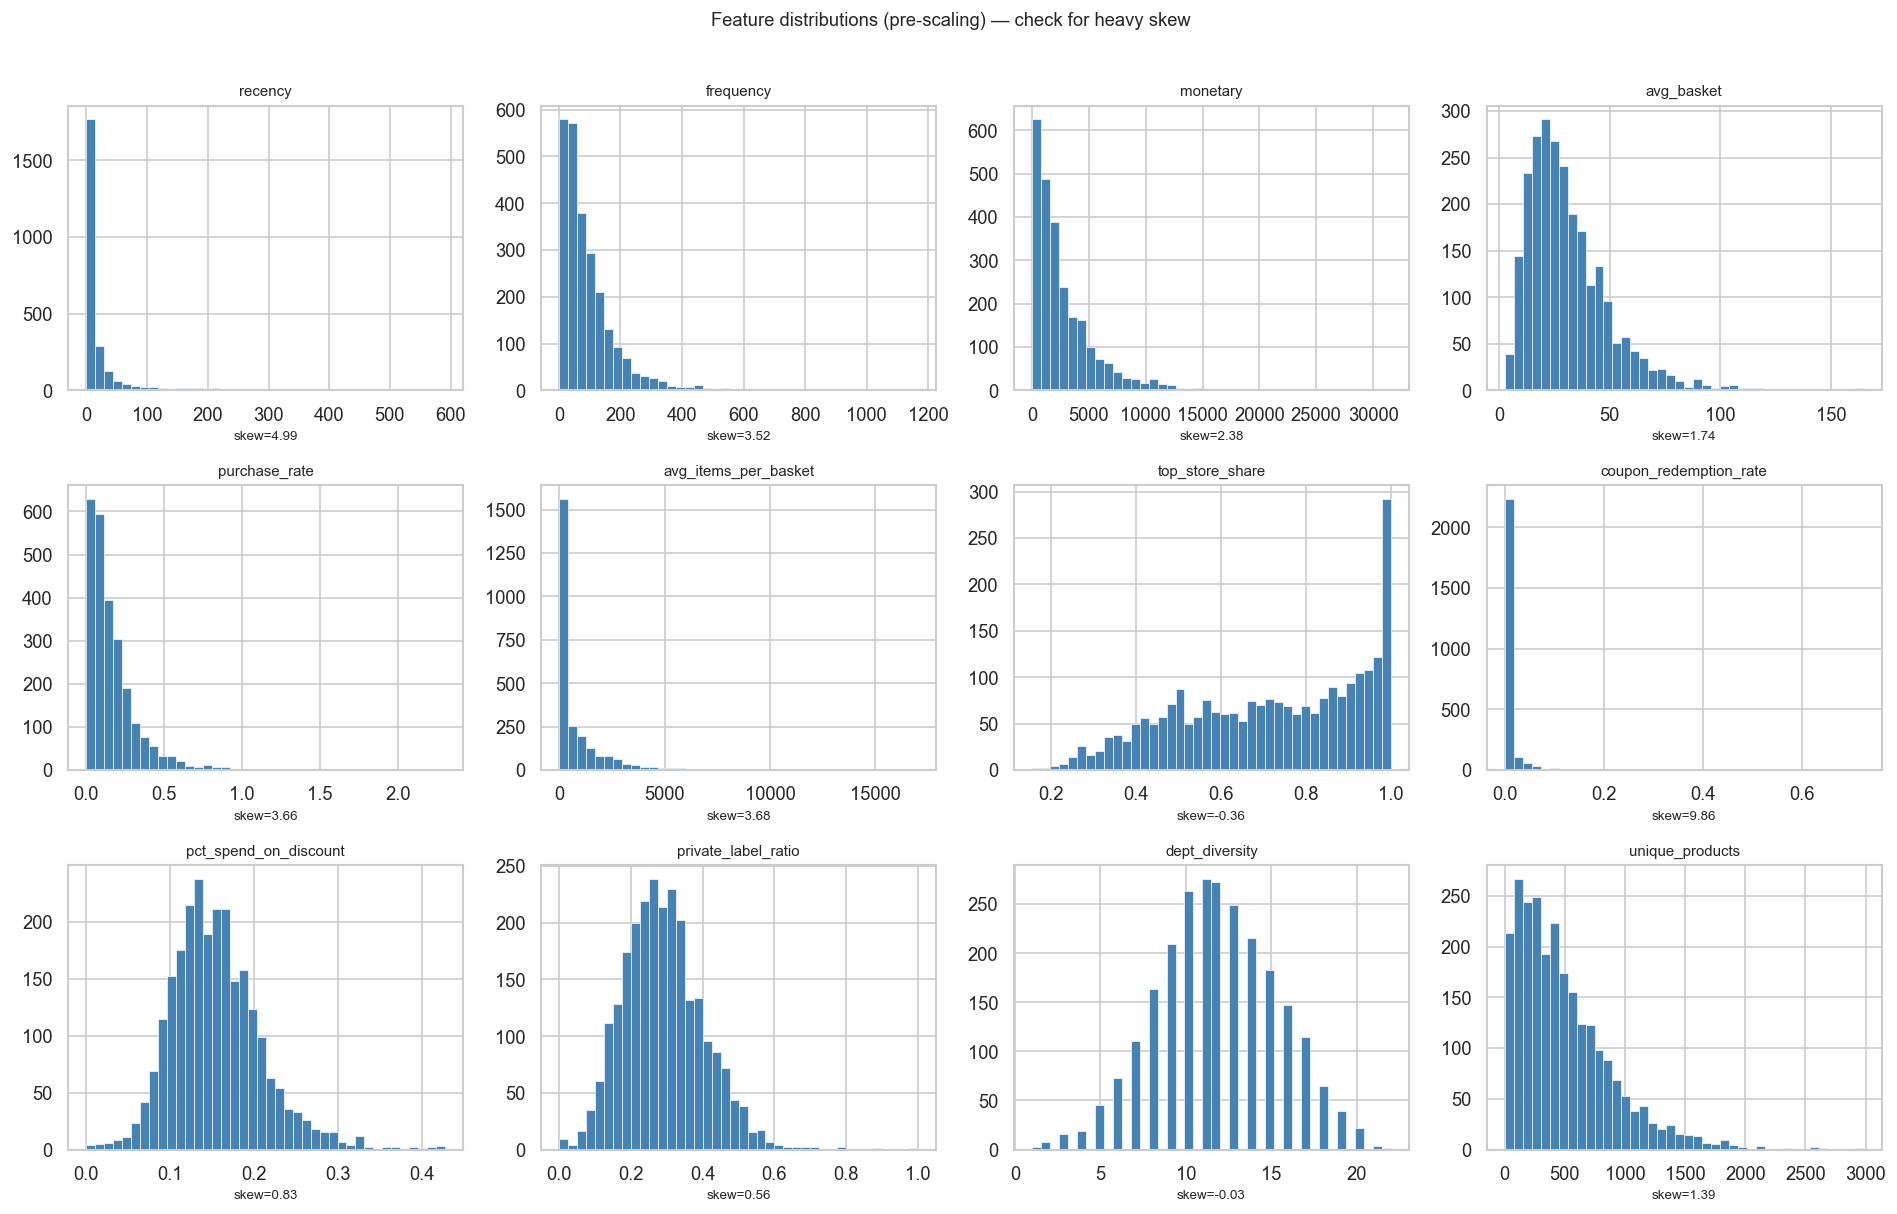


Highly skewed features (skew > 1.5): ['recency', 'frequency', 'monetary', 'avg_basket', 'purchase_rate', 'avg_items_per_basket', 'coupon_redemption_rate']
These will be log1p-transformed before clustering.


In [8]:
numeric_cols = [
    'recency', 'frequency', 'monetary', 'avg_basket',
    'purchase_rate', 'avg_items_per_basket', 'top_store_share',
    'coupon_redemption_rate', 'pct_spend_on_discount',
    'private_label_ratio', 'dept_diversity', 'unique_products'
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(feature_matrix[col].dropna(), bins=40,
                 color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].set_title(col, fontsize=9)
    skew = feature_matrix[col].skew()
    axes[i].set_xlabel(f'skew={skew:.2f}', fontsize=8)

fig.suptitle('Feature distributions (pre-scaling) — check for heavy skew',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# Log-transform highly skewed features (skew > 1.5)
skewed = [c for c in numeric_cols if feature_matrix[c].skew() > 1.5]
print(f"\nHighly skewed features (skew > 1.5): {skewed}")
print("These will be log1p-transformed before clustering.")

for col in skewed:
    feature_matrix[f'{col}_log'] = np.log1p(feature_matrix[col])

In [9]:
# Fill any remaining nulls in numeric cols with median
num_cols_all = feature_matrix.select_dtypes(include=np.number).columns
feature_matrix[num_cols_all] = feature_matrix[num_cols_all].fillna(
    feature_matrix[num_cols_all].median()
)

# Save
out_path = 'data/feature_matrix.csv'
feature_matrix.to_csv(out_path, index=False)
print(f"✓ Saved feature matrix → {out_path}")
print(f"  Shape      : {feature_matrix.shape}")
print(f"  Households : {feature_matrix['household_key'].nunique():,}")
print(f"  Churned    : {feature_matrix['churned'].sum()} ({feature_matrix['churned'].mean()*100:.1f}%)")
print(f"  Features   : {feature_matrix.shape[1] - 1} (excl. household_key)")

print("\n✓ Phase 2 complete. Ready for Phase 3 (Segmentation).")

✓ Saved feature matrix → data/feature_matrix.csv
  Shape      : (2499, 42)
  Households : 2,499
  Churned    : 171 (6.8%)
  Features   : 41 (excl. household_key)

✓ Phase 2 complete. Ready for Phase 3 (Segmentation).
